● Fetch latest news articles
● Categorize news topics
● Analyze sentiment
● Count trending keywords
● Generate visual reports
● Compare news categories

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import requests 

API_KEY="42477ed803dc49018e87a0df1a04d535"
url = f"https://newsapi.org/v2/top-headlines?country=us&apiKey={API_KEY}"

response = requests.get(url)

data = response.json()

articles = data["articles"]

news = []

for article in articles:
    news.append({
        "Title": article["title"],
        "Source": article["source"]["name"],
        "Published": article["publishedAt"]
    })

df = pd.DataFrame(news)

print(df)

                                                Title  \
0   World Cup Daily live: Harry Kane loses voice i...   
1   Jordan Henderson to reportedly undergo wrist s...   
2   Microsoft cuts 4,800 jobs, as Xbox unit downsi...   
3   Buckingham Palace says Prince Harry not stayin...   
4   Trump rings NYSE, Nasdaq opening bells from Wh...   
5   NBA Executives React to Jaylen Brown Trade - H...   
6   2 National Guard members on patrol in Memphis ...   
7   Stock Market Today: Nasdaq Futures Rise Ahead ...   
8   Wild Details of Allies’ Secret Summit to Deal ...   
9   Prosecutors argue the man accused of killing C...   
10  ‘Minions & Monsters’ tops Fourth of July holid...   
11  Euclid telescope spots oldest quasars ever dis...   
12  Why U.S. measles outbreaks have grown harder t...   
13  Chris Christie Compares Trump’s $1.4 Billion C...   
14  Young Castro wants Trump to deal: his exclusiv...   
15  First experiment to thicken Arctic ice with se...   
16  Paul McCartney sang a Beatl

In [2]:
print(df[["Title","Source","Published"]])

                                                Title  \
0   World Cup Daily live: Harry Kane loses voice i...   
1   Jordan Henderson to reportedly undergo wrist s...   
2   Microsoft cuts 4,800 jobs, as Xbox unit downsi...   
3   Buckingham Palace says Prince Harry not stayin...   
4   Trump rings NYSE, Nasdaq opening bells from Wh...   
5   NBA Executives React to Jaylen Brown Trade - H...   
6   2 National Guard members on patrol in Memphis ...   
7   Stock Market Today: Nasdaq Futures Rise Ahead ...   
8   Wild Details of Allies’ Secret Summit to Deal ...   
9   Prosecutors argue the man accused of killing C...   
10  ‘Minions & Monsters’ tops Fourth of July holid...   
11  Euclid telescope spots oldest quasars ever dis...   
12  Why U.S. measles outbreaks have grown harder t...   
13  Chris Christie Compares Trump’s $1.4 Billion C...   
14  Young Castro wants Trump to deal: his exclusiv...   
15  First experiment to thicken Arctic ice with se...   
16  Paul McCartney sang a Beatl

In [3]:
category = []

for title in df["Title"]:

    title = title.lower()

    if "ai" in title or "technology" in title:
        category.append("Technology")

    elif "market" in title or "stock" in title:
        category.append("Business")

    elif "cricket" in title or "football" in title:
        category.append("Sports")

    elif "health" in title:
        category.append("Health")

    else:
        category.append("General")

df["Category"] = category

print(df[["Title","Category"]])

                                                Title    Category
0   World Cup Daily live: Harry Kane loses voice i...  Technology
1   Jordan Henderson to reportedly undergo wrist s...     General
2   Microsoft cuts 4,800 jobs, as Xbox unit downsi...     General
3   Buckingham Palace says Prince Harry not stayin...     General
4   Trump rings NYSE, Nasdaq opening bells from Wh...     General
5   NBA Executives React to Jaylen Brown Trade - H...     General
6   2 National Guard members on patrol in Memphis ...     General
7   Stock Market Today: Nasdaq Futures Rise Ahead ...    Business
8   Wild Details of Allies’ Secret Summit to Deal ...  Technology
9   Prosecutors argue the man accused of killing C...     General
10  ‘Minions & Monsters’ tops Fourth of July holid...     General
11  Euclid telescope spots oldest quasars ever dis...     General
12  Why U.S. measles outbreaks have grown harder t...     General
13  Chris Christie Compares Trump’s $1.4 Billion C...     General
14  Young 

In [4]:
positive = ["good","growth","success","win","profit","best","record"]
negative = ["loss","fall","crash","war","bad","decline","fraud"]

sentiment = []

for title in df["Title"]:

    t = title.lower()

    if any(word in t for word in positive):
        sentiment.append("Positive")

    elif any(word in t for word in negative):
        sentiment.append("Negative")

    else:
        sentiment.append("Neutral")

df["Sentiment"] = sentiment

print(df[["Title","Sentiment"]])

                                                Title Sentiment
0   World Cup Daily live: Harry Kane loses voice i...   Neutral
1   Jordan Henderson to reportedly undergo wrist s...  Positive
2   Microsoft cuts 4,800 jobs, as Xbox unit downsi...   Neutral
3   Buckingham Palace says Prince Harry not stayin...   Neutral
4   Trump rings NYSE, Nasdaq opening bells from Wh...   Neutral
5   NBA Executives React to Jaylen Brown Trade - H...   Neutral
6   2 National Guard members on patrol in Memphis ...   Neutral
7   Stock Market Today: Nasdaq Futures Rise Ahead ...   Neutral
8   Wild Details of Allies’ Secret Summit to Deal ...   Neutral
9   Prosecutors argue the man accused of killing C...   Neutral
10  ‘Minions & Monsters’ tops Fourth of July holid...   Neutral
11  Euclid telescope spots oldest quasars ever dis...   Neutral
12  Why U.S. measles outbreaks have grown harder t...   Neutral
13  Chris Christie Compares Trump’s $1.4 Billion C...   Neutral
14  Young Castro wants Trump to deal: hi

In [5]:
words = []

for title in df["Title"]:
    for word in title.lower().split():
        words.append(word)

keyword_count = {}

for word in words:

    if word in keyword_count:
        keyword_count[word] += 1
    else:
        keyword_count[word] = 1

print(keyword_count)

{'world': 2, 'cup': 2, 'daily': 2, 'live:': 1, 'harry': 2, 'kane': 1, 'loses': 1, 'voice': 1, 'in': 4, 'hilarious': 1, 'interview,': 1, 'usmnt': 1, 'prepares': 1, 'for': 2, 'belgium': 1, '-': 18, 'espn': 1, 'jordan': 1, 'henderson': 1, 'to': 10, 'reportedly': 1, 'undergo': 1, 'wrist': 1, 'surgery,': 1, 'miss': 1, 'rest': 1, 'of': 7, 'after': 1, 'injuring': 1, 'himself': 1, 'while': 1, 'celebrating': 1, "england's": 1, 'win': 1, 'over': 1, 'mexico': 1, 'yahoo': 2, 'sports': 1, 'microsoft': 1, 'cuts': 1, '4,800': 1, 'jobs,': 1, 'as': 1, 'xbox': 1, 'unit': 1, 'downsizes': 1, 'and': 1, 'plans': 1, 'spin': 1, 'off': 1, 'four': 1, 'gaming': 1, 'studios': 1, 'cnbc': 1, 'buckingham': 1, 'palace': 1, 'says': 1, 'prince': 1, 'not': 1, 'staying': 1, 'there': 1, 'on': 2, 'u.k.': 1, 'visit,': 1, 'contradicting': 1, 'his': 2, 'spokesperson': 1, 'cbs': 3, 'news': 5, 'trump': 4, 'rings': 1, 'nyse,': 1, 'nasdaq': 2, 'opening': 1, 'bells': 1, 'from': 1, 'white': 1, 'house': 1, 'celebrate': 1, 'launch': 

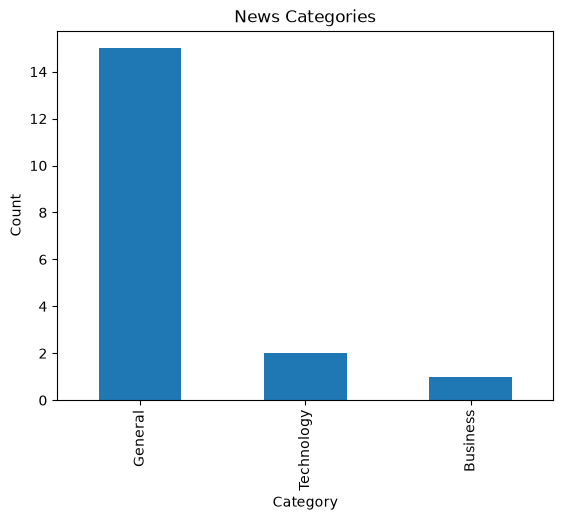

In [6]:
df["Category"].value_counts().plot(kind="bar")

plt.title("News Categories")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

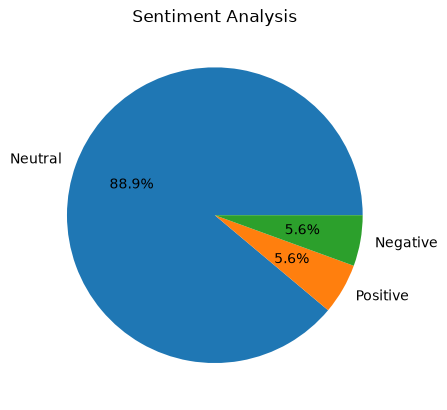

In [7]:
df["Sentiment"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Sentiment Analysis")

plt.ylabel("")

plt.show()

Category
General       15
Technology     2
Business       1
Name: count, dtype: int64


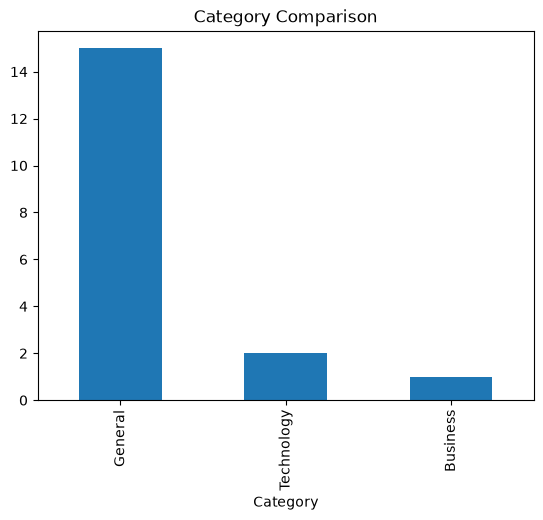

In [8]:
comparison = df["Category"].value_counts()

print(comparison)

comparison.plot(kind="bar")

plt.title("Category Comparison")

plt.show()